# Data Mining and Machine Learning Project
## Falaschi Dario - Masiero Chiara

#1. Imports & load cleaned dataset



In [ ]:
!pip install -q catboost imbalanced-learn shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.4 MB/s eta 0:00:00


In [ ]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from google.colab import drive
import os
import json
import datetime

# Sklearn — preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Sklearn — model selection
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)
from sklearn.model_selection import cross_validate

# Sklearn — models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Boosting model
from catboost import CatBoostClassifier

# Imbalanced learning
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

# Statistical test
from scipy.stats import wilcoxon

# Progress Bar
from tqdm.notebook import tqdm
import time
import datetime

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('All libraries imported successfully.')

All libraries imported successfully.


In [ ]:
# Drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/DMML_Project/online_shoppers_cleaned.csv'

# Dataset Loading
df = pd.read_csv(file_path, dtype={
    'OperatingSystems': str,
    'Browser': str,
    'Region': str,
    'TrafficType': str
})
display(df.head())

Mounted at /content/drive


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# 2. Define X and Y
Before building the Nested Cross-Validation loop, we must define our feature matrix (`X`) and target vector (`y`).

In [ ]:
X = df.drop(columns=["Revenue"])
y = df["Revenue"].astype(int)

print("--- X and y defined on the ENTIRE dataset ---")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nClass distribution:")
counts = y.value_counts()
pcts = y.value_counts(normalize=True) * 100
for cls in [0, 1]:
    print(f"  Class {cls}: {counts[cls]} samples ({pcts[cls]:.1f}%)")

--- X and y defined on the ENTIRE dataset ---
X shape: (12205, 15)
y shape: (12205,)

Class distribution:
  Class 0: 10297 samples (84.4%)
  Class 1: 1908 samples (15.6%)


# 3. Define Preprocessor

The preprocessor is **defined here but never applied directly** to the data.

It will be applied inside the pipeline at each fold to prevent data leakage.

We define the `ColumnTransformer` to handle feature scaling (for numerical variables) and `One-Hot Encoding` (for categorical variables) dynamically within the validation pipelines.


In [ ]:
# Numerical features — scaled with StandardScaler
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Numerical column names  : {numerical_features}')

# Categorical features — encoded with OneHotEncoder
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f'Categorical column names  : {categorical_features}')

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_features)
])

print('Preprocessor defined (not yet applied)')

Numerical column names  : ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ExitRates', 'PageValues', 'SpecialDay']
Categorical column names  : ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
Preprocessor defined (not yet applied)


# 4. Define SMOTENC

**SMOTENC** (Synthetic Minority Oversampling for Nominal and Continuous features)
is used instead of standard SMOTE because the dataset contains a mix of
numerical and categorical features.

For numerical features it interpolates values between neighbors.
For categorical features it selects the most frequent category among neighbors.

SMOTENC is placed **before** the preprocessor in the pipeline,
working on the original feature space before OHE transforms the categoricals.
It requires the **integer indices** of the categorical columns in X.



In [ ]:
# SMOTENC requires integer indices of categorical columns in X
categorical_indices = [X.columns.get_loc(col) for col in categorical_features]

print(f'Categorical column indices: {categorical_indices}')

smotenc = SMOTENC(categorical_features=categorical_indices, random_state=42)
print('\nSMOTENC initialized successfully.')


Categorical column indices: [8, 9, 10, 11, 12, 13, 14]

SMOTENC initialized successfully.


# 5. Define Models and Hyperparameter Grids

We define the dictionaries of hyperparameters that our inner Cross-Validation loop will search through to optimize model performance. We set up grids for a diverse set of algorithms to ensure a comprehensive comparison:
1. **Random Forest** (Bagging ensemble)
2. **Support Vector Machine (SVM)** (Margin-based classifier)
3. **Decision Tree** (Simple interpretable baseline)
4. **K-Nearest Neighbors (KNN)** (Distance-based classifier)
5. **CatBoost** (Advanced Gradient Boosting)

SVM grid is intentionally small (3 combinations) to keep computational cost manageable
in the 10×10 nested CV with ~12k samples.

In [ ]:
models_and_grids = {
    'Decision Tree': (DecisionTreeClassifier(random_state=42), {
        'classifier__max_depth': [3, 5, 10],
        'classifier__min_samples_leaf': [20, 50],
    }),
    'Random Forest': (RandomForestClassifier(random_state=42, n_jobs=-1), {
        'classifier__n_estimators': [100, 150],
        'classifier__max_depth': [10, 20],
        'classifier__min_samples_leaf': [10,20],
    }),
    'SVM': (SVC(random_state=42),{
            'classifier__C':      [0.1, 1, 10],
    }),
    'CatBoost': (CatBoostClassifier(random_state=42, verbose=0), {
        'classifier__iterations': [100, 200],
        'classifier__learning_rate': [0.01, 0.05],
        'classifier__depth': [3, 5],
    }),
    'KNN': (KNeighborsClassifier(), {
             'classifier__n_neighbors': [3, 5, 7],
            'classifier__weights': ['uniform', 'distance'],
    })
}

print('\nModels and grids defined:')
for name, (model, grid) in models_and_grids.items():
    n_combinations = 1
    for v in grid.values():
        n_combinations *= len(v)
    print(f'  {name:<20}: {n_combinations:>3} hyperparameter combinations')



Models and grids defined:
  Decision Tree       :   6 hyperparameter combinations
  Random Forest       :   8 hyperparameter combinations
  SVM                 :   3 hyperparameter combinations
  CatBoost            :   8 hyperparameter combinations
  KNN                 :   6 hyperparameter combinations


#6. Checkpoint Management



## 6.a Checkpoint Recovery
Run this cell to loads the partial results
saved on Drive and resumes from where it left off.

In [ ]:
CHECKPOINT_PATH = '/content/drive/MyDrive/DMML_Project/nested_cv_checkpoint.json'
SCORING_METRICS = ['accuracy', 'precision', 'recall', 'f1']

if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH) as f:
        saved = json.load(f)
    all_results = {
        metric: {name: np.array(scores) for name, scores in models.items()}
        for metric, models in saved.items()
    }
    print('Checkpoint loaded successfully from Drive. Can skip the training loop.')
    for metric, models in all_results.items():
        print(f'  {metric}: {list(models.keys())}')
else:
    all_results = {metric: {} for metric in SCORING_METRICS}
    print('No checkpoint found on Drive. A fresh run will be required.')

Checkpoint loaded successfully from Drive. Can skip the training loop.
  accuracy: ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost', 'KNN']
  precision: ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost', 'KNN']
  recall: ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost', 'KNN']
  f1: ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost', 'KNN']


##6.b Checkpoint Reset
Runs during "Run All" to fresh start the training.

In [ ]:
CHECKPOINT_PATH = '/content/drive/MyDrive/DMML_Project/nested_cv_checkpoint.json'
SCORING_METRICS = ['accuracy', 'precision', 'recall', 'f1']

# Reset checkpoint and results before re-running nested CV
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print('Old checkpoint deleted.')
else:
    print('No checkpoint found.')

# Reset all_results
all_results = {metric: {} for metric in SCORING_METRICS}
print('Memory initialized fresh. Ready to train all models.')

Old checkpoint deleted.
Memory initialized fresh. Ready to train all models.


# 7. Nested Cross-Validation 10×10

### Nested CV logic:
- **Outer loop (10 folds)**: produces one unbiased score per fold → distribution of 10 scores
- **Inner loop (10 folds)**: GridSearchCV finds the best hyperparameters for each outer fold

The outer test fold is **never seen** during hyperparameter tuning or preprocessing fit.

We analyse the follwing metrics:
- Accuracy
- Precision
- Recall
- F1-score

Results are saved to Drive after each model (checkpoint).


In [ ]:
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
inner_cv  = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, (model, param_grid) in tqdm(models_and_grids.items(), desc='Nested CV', leave=True):
    start = time.time()
    pipeline = ImbPipeline(steps=[
        ('smotenc',      smotenc),
        ('preprocessor', preprocessor),
        ('classifier',   model)
    ])
    # Inner loop
    inner_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=inner_cv,
                                scoring='f1', n_jobs=-1, refit=True)
    # Outer loop
    cv_results = cross_validate(estimator=inner_search, X=X, y=y, cv=outer_cv,
                                scoring=SCORING_METRICS, n_jobs=-1, return_estimator=True)

    # Best params for every outer fold
    print(f'\n  {name} — best params per outer fold:')
    for fold_i, estimator in enumerate(cv_results['estimator']):
        print(f'    Fold {fold_i+1}: {estimator.best_params_}')

    elapsed = time.time() - start

    # Save the results for each metric
    for metric in SCORING_METRICS:
        all_results[metric][name] = cv_results[f'test_{metric}']

    print(f'  {name:<20} '
          f'| Accuracy={all_results["accuracy"][name].mean():.4f} '
          f'| Precision={all_results["precision"][name].mean():.4f} '
          f'| Recall={all_results["recall"][name].mean():.4f} '
          f'| F1={all_results["f1"][name].mean():.4f} '
          f'| {elapsed:.0f}s')

    # Checkpoint
    checkpoint = {
        m: {k: v.tolist() for k, v in s.items()}
        for m, s in all_results.items()
    }
    with open(CHECKPOINT_PATH, 'w') as f:
        json.dump(checkpoint, f, indent=2)
    print(f'  Checkpoint saved!')

print('\nAll nested CV runs completed!')

Nested CV:   0%|          | 0/5 [00:00<?, ?it/s]


  Decision Tree — best params per outer fold:
    Fold 1: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 20}
    Fold 2: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 20}
    Fold 3: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 20}
    Fold 4: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 20}
    Fold 5: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 20}
    Fold 6: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 20}
    Fold 7: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 20}
    Fold 8: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 20}
    Fold 9: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 20}
    Fold 10: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 20}
  Decision Tree        | Accuracy=0.8720 | Precision=0.5641 | Recall=0.8061 | F1=0.6634 | 945s
  Checkpoint saved!

  Random Forest — best params per outer fold:
    Fold 1: {'classi

##7a. Hardcode Results

After the nested CV completes, hardcode the results here.
This allows the notebook to be restarted without re-running the nested CV.


In [ ]:
with open(CHECKPOINT_PATH) as f:
    saved = json.load(f)

all_results_hardcoded = {
    metric: {
        name: np.array(scores)
        for name, scores in models.items()
    }
    for metric, models in saved.items()
}

all_results = all_results_hardcoded

print('Results loaded from checkpoint:')
for metric, models in all_results.items():
    print(f'  {metric}: {list(models.keys())}')
print(f'\nSCORING_METRICS: {SCORING_METRICS}')

Results loaded from checkpoint:
  accuracy: ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost', 'KNN']
  precision: ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost', 'KNN']
  recall: ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost', 'KNN']
  f1: ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost', 'KNN']

SCORING_METRICS: ['accuracy', 'precision', 'recall', 'f1']


#8. Ablation Study Without SMOTENC

To scientifically validate the necessity of addressing the class imbalance, we performed an **ablation study** running the Nested Cross-Validation without the SMOTENC oversampling step.

##8.a Checkpoint Recovery
Run this cell to loads the partial results
saved on Drive and resumes from where it left off.

In [ ]:
CHECKPOINT_PATH_NS = '/content/drive/MyDrive/DMML_Project/nested_cv_no_smotenc.json'

if os.path.exists(CHECKPOINT_PATH_NS):
    with open(CHECKPOINT_PATH_NS) as f:
        saved = json.load(f)
    all_results_no_smotenc = {
        metric: {name: np.array(scores) for name, scores in models.items()}
        for metric, models in saved.items()
    }
    print('Checkpoint loaded successfully from Drive. Can skip the training loop.')
    for metric, models in all_results_no_smotenc.items():
        print(f'  {metric}: {list(models.keys())}')
else:
    all_results_no_smotenc = {metric: {} for metric in SCORING_METRICS}
    print('No checkpoint found on Drive. A fresh run will be required.')

No checkpoint found on Drive. A fresh run will be required.


##8.b Checkpoint Reset
Runs during "Run All" to fresh start the training.

In [ ]:
# Reset checkpoint and results before re-running nested CV
if os.path.exists(CHECKPOINT_PATH_NS):
    os.remove(CHECKPOINT_PATH_NS)
    print('Old checkpoint deleted.')
else:
    print('No checkpoint found.')

# Reset all_results
all_results_no_smotenc = {metric: {} for metric in SCORING_METRICS}
print('Memory initialized fresh. Ready to train all models.')

No checkpoint found.
Memory initialized fresh. Ready to train all models.


##8.c Nested CV without SMOTENC

In [ ]:
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
inner_cv  = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, (model, param_grid) in tqdm( models_and_grids.items(), desc='Nested CV (NO SMOTENC)', leave=True):
    start = time.time()
    pipeline_ns = ImbPipeline(steps=[
        # No SMOTENC
        ('preprocessor', preprocessor),
        ('classifier',   model)
    ])

    inner_search = GridSearchCV(estimator=pipeline_ns, param_grid=param_grid, cv=inner_cv,
                                scoring='f1', n_jobs=-1, refit=True)

    cv_results = cross_validate(estimator=inner_search, X=X, y=y, cv=outer_cv,
                                scoring=SCORING_METRICS, n_jobs=-1)

    elapsed = time.time() - start

    for metric in SCORING_METRICS:
        all_results_no_smotenc[metric][name] = cv_results[f'test_{metric}']

    print(f'  {name:<20} '
          f'| Accuracy={all_results_no_smotenc["accuracy"][name].mean():.4f} '
          f'| Precision={all_results_no_smotenc["precision"][name].mean():.4f} '
          f'| Recall={all_results_no_smotenc["recall"][name].mean():.4f} '
          f'| F1={all_results_no_smotenc["f1"][name].mean():.4f} '
          f'| {elapsed:.0f}s')

    # Checkpoint
    checkpoint = {
        m: {k: v.tolist() for k, v in s.items()}
        for m, s in all_results_no_smotenc.items()
    }
    with open(CHECKPOINT_PATH_NS, 'w') as f:
        json.dump(checkpoint, f, indent=2)
    print(f'  Checkpoint saved!')

print(f'\nAll nested CV (NO SMOTENC) runs completed!')

Nested CV (NO SMOTENC):   0%|          | 0/5 [00:00<?, ?it/s]

  Decision Tree        | Accuracy=0.8995 | Precision=0.7159 | Recall=0.5980 | F1=0.6502 | 71s
  Checkpoint saved!
  Random Forest        | Accuracy=0.8982 | Precision=0.7929 | Recall=0.4728 | F1=0.5918 | 2167s
  Checkpoint saved!
  SVM                  | Accuracy=0.8910 | Precision=0.7014 | Recall=0.5309 | F1=0.6037 | 1186s
  Checkpoint saved!
  CatBoost             | Accuracy=0.9010 | Precision=0.7161 | Recall=0.6095 | F1=0.6582 | 540s
  Checkpoint saved!
  KNN                  | Accuracy=0.8682 | Precision=0.6301 | Recall=0.3947 | F1=0.4835 | 454s
  Checkpoint saved!

All nested CV (NO SMOTENC) runs completed!


##8.d Hardcode results

This cell retrieves the calculated metrics from Google Drive.

In [ ]:
with open(CHECKPOINT_PATH_NS) as f:
    saved = json.load(f)

all_results_hardcoded = {
    metric: {
        name: np.array(scores)
        for name, scores in models.items()
    }
    for metric, models in saved.items()
}

all_results_no_smotenc = all_results_hardcoded
print('Results loaded from checkpoint:')
for metric, models in all_results_no_smotenc.items():
    print(f'  {metric}: {list(models.keys())}')
print(f'\nSCORING_METRICS: {SCORING_METRICS}')

Results loaded from checkpoint:
  accuracy: ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost', 'KNN']
  precision: ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost', 'KNN']
  recall: ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost', 'KNN']
  f1: ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost', 'KNN']

SCORING_METRICS: ['accuracy', 'precision', 'recall', 'f1']


## 8.e SMOTENC VS NO-SMOTENC Comparison

To conclude the analysis of the sampling technique, we compute the mean scores across the folds and compare them directly using grouped bar charts.

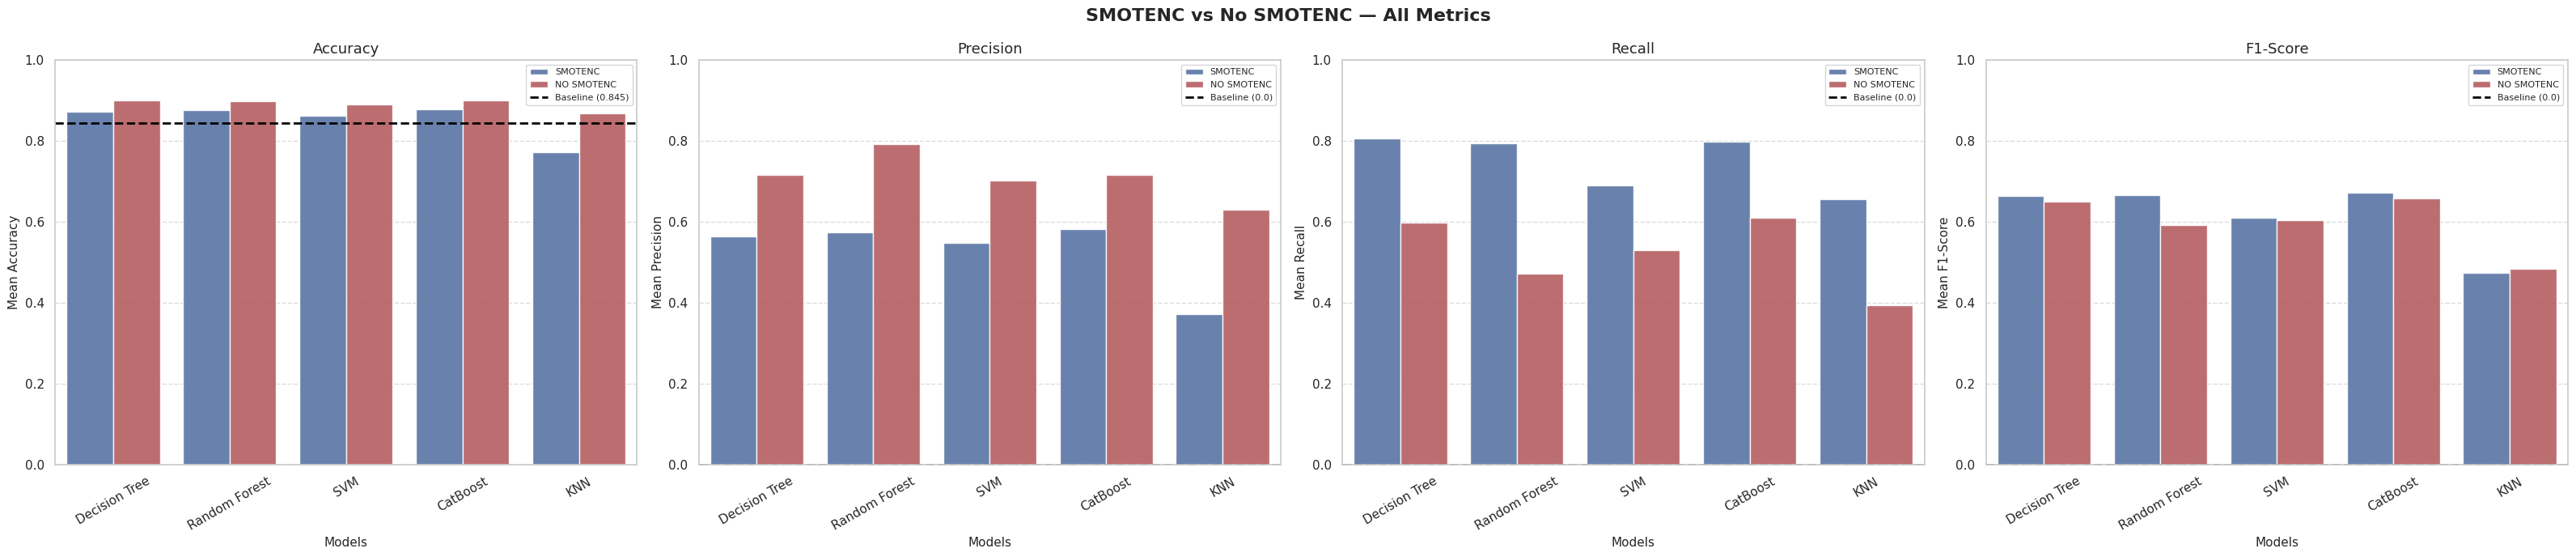

Plot saved: ablation_all_metrics.png


In [ ]:

palette_colors = {'SMOTENC': '#4C72B0', 'NO SMOTENC': '#C44E52'}

metric_labels = {
    'accuracy':  'Accuracy',
    'precision': 'Precision',
    'recall':    'Recall',
    'f1':        'F1-Score',
}

baselines = {
    'f1':        0.0,
    'precision': 0.0,
    'recall':    0.0,
    'accuracy':  0.845
}

fig, axes = plt.subplots(1, 4, figsize=(32, 7))
fig.suptitle('SMOTENC vs No SMOTENC — All Metrics', fontsize=16, fontweight='bold')

metrics_order = ['accuracy', 'precision','recall','f1']

for ax, metric in zip(axes, metrics_order):
    data_rows = []
    for name in models_and_grids.keys():
        data_rows.append({
            'Model':     name,
            'Condition': 'SMOTENC',
            'Score':     all_results[metric][name].mean()
        })
        data_rows.append({
            'Model':     name,
            'Condition': 'NO SMOTENC',
            'Score':     all_results_no_smotenc[metric][name].mean()
        })

    summary_df = pd.DataFrame(data_rows)

    sns.barplot(
        data=summary_df,
        x='Model', y='Score',
        hue='Condition',
        palette=palette_colors,
        alpha=0.9,
        ax=ax
    )
    ax.set_title(f'{metric_labels[metric]}', fontsize=13)
    ax.set_ylabel(f'Mean {metric_labels[metric]}', fontsize=11)
    ax.set_xlabel('Models', fontsize=11)
    ax.set_ylim(0, 1)

    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.axhline(
        y=baselines[metric],
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'Baseline ({baselines[metric]})'
    )
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/ablation_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: ablation_all_metrics.png')

The side-by-side plots demonstrate that without SMOTENC the models achieve a higher overall Accuracy (by favoring the majority class) but suffer a drop in the F1-Score, proving their decreased ability to correctly identify actual buyers.

When analyzing imbalanced datasets, Accuracy is a misleading metric.

--> A model that classifies every user session as a non-purchase (`Revenue = False`) would achieve a baseline accuracy of approximately **84.5%**.

We must closely examine the interaction between **Precision** and **Recall**:

- **Without SMOTENC:**
   * **Precision** (minimizing False Positives) inflates because the models become extremely conservative.

- **With SMOTENC:**
   * The models become significantly more sensitive, provoking an increase in **Recall** (minimizing False Negatives).


This trade-off is favorable for the e-commerce platform due to the costs of misclassification.

False Negatives --> If the model fails to detect an actual buyer, the system takes no action and the customer leaves the platform without completing the purchase, resulting in a direct loss of potential revenue.

False Positives--> If a casual browser is misclassified as a potential buyer, the system might trigger an automated conversion strategy (e.g., displaying discount pop-up). While the user may still choose not to buy, the cost of showing a web banner is  zero to the platform infrastructure.

By incorporating SMOTENC, we intentionally accept sacrifice in Precision to maximize Recall.

# 9. Model Comparison and Winner Selection

We compare models using:
1. **Summary table**: mean, std, min, max per metric
2. **Boxplot with stripplot**: score distributions per model (one plot per metric)
3. **Wilcoxon signed-rank test**: statistical significance between top 2 models


In [ ]:
# --- Summary Tables ---
for metric in SCORING_METRICS:
    df_metric = pd.DataFrame(all_results[metric])
    summary = pd.DataFrame({
        'Mean': df_metric.mean(),
        'Std':  df_metric.std(),
        'Min':  df_metric.min(),
        'Max':  df_metric.max()
    }).round(4).sort_values('Mean', ascending=False)
    print(f'\n--- {metric.upper()} ---')
    print(summary.to_string())


--- ACCURACY ---
                 Mean     Std     Min     Max
CatBoost       0.8785  0.0112  0.8623  0.8976
Random Forest  0.8757  0.0088  0.8623  0.8919
Decision Tree  0.8720  0.0122  0.8557  0.8927
SVM            0.8623  0.0102  0.8434  0.8812
KNN            0.7728  0.0119  0.7500  0.7903

--- PRECISION ---
                 Mean     Std     Min     Max
CatBoost       0.5819  0.0282  0.5401  0.6289
Random Forest  0.5745  0.0219  0.5404  0.6166
Decision Tree  0.5641  0.0286  0.5251  0.6145
SVM            0.5476  0.0261  0.5000  0.5975
KNN            0.3713  0.0220  0.3371  0.4047

--- RECALL ---
                 Mean     Std     Min     Max
Decision Tree  0.8061  0.0364  0.7330  0.8482
CatBoost       0.7977  0.0313  0.7330  0.8429
Random Forest  0.7951  0.0302  0.7487  0.8325
SVM            0.6897  0.0287  0.6545  0.7382
KNN            0.6562  0.0602  0.5789  0.7316

--- F1 ---
                 Mean     Std     Min     Max
CatBoost       0.6726  0.0263  0.6422  0.7204
Random Forest  

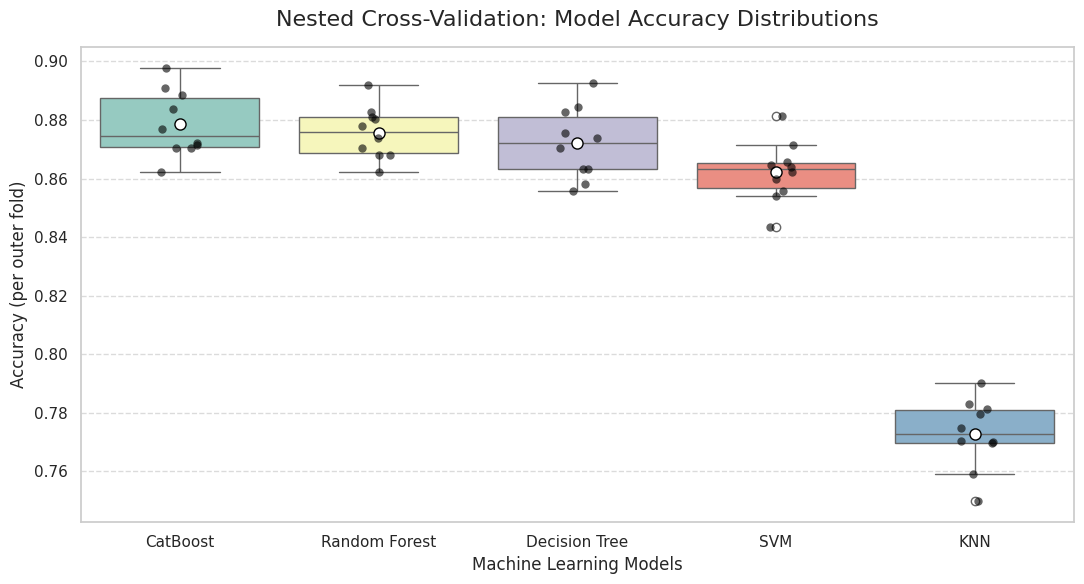

Plot saved: nested_cv_accuracy.png


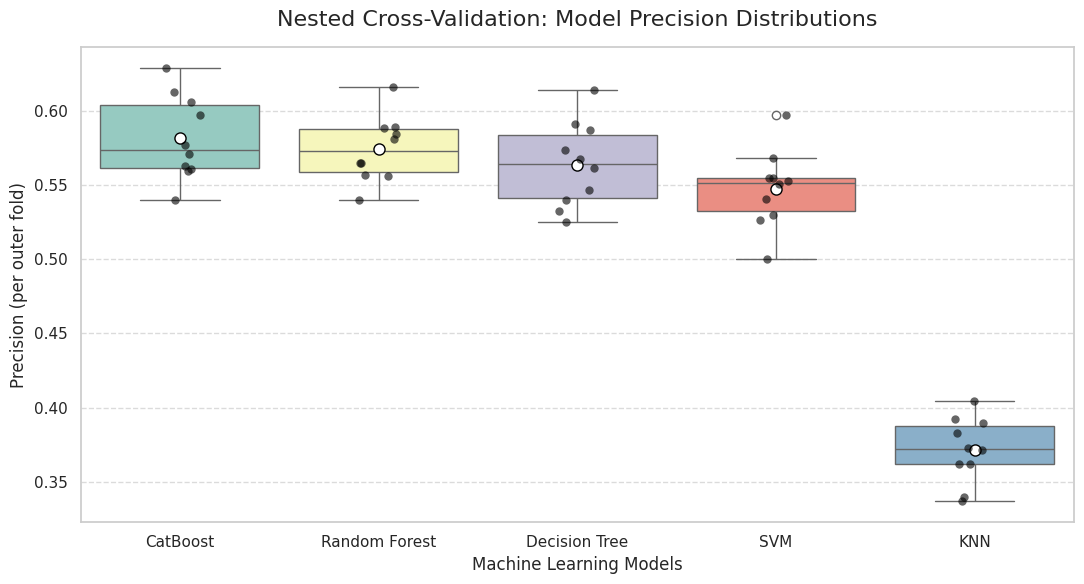

Plot saved: nested_cv_precision.png


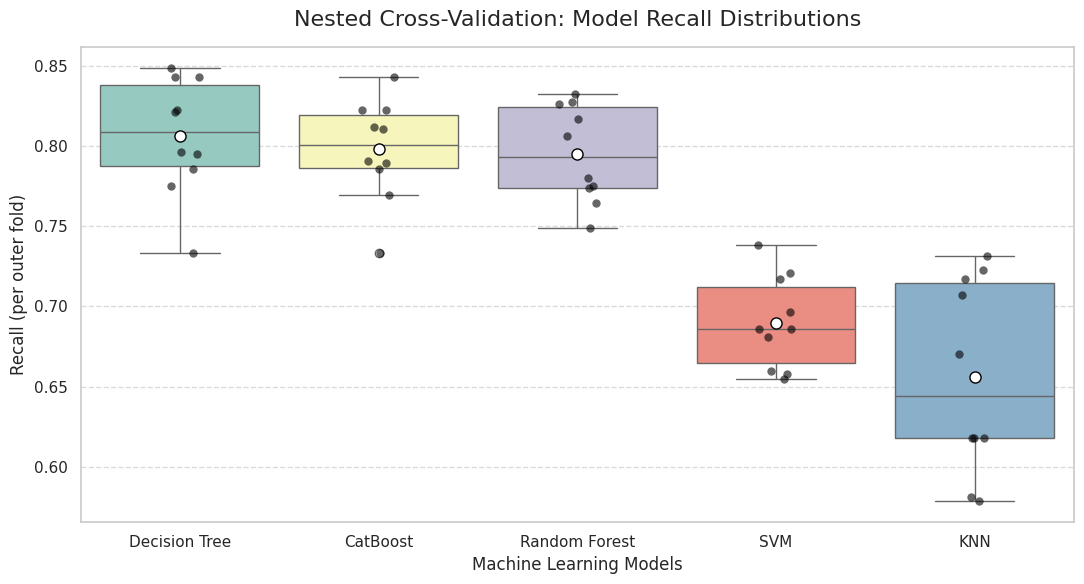

Plot saved: nested_cv_recall.png


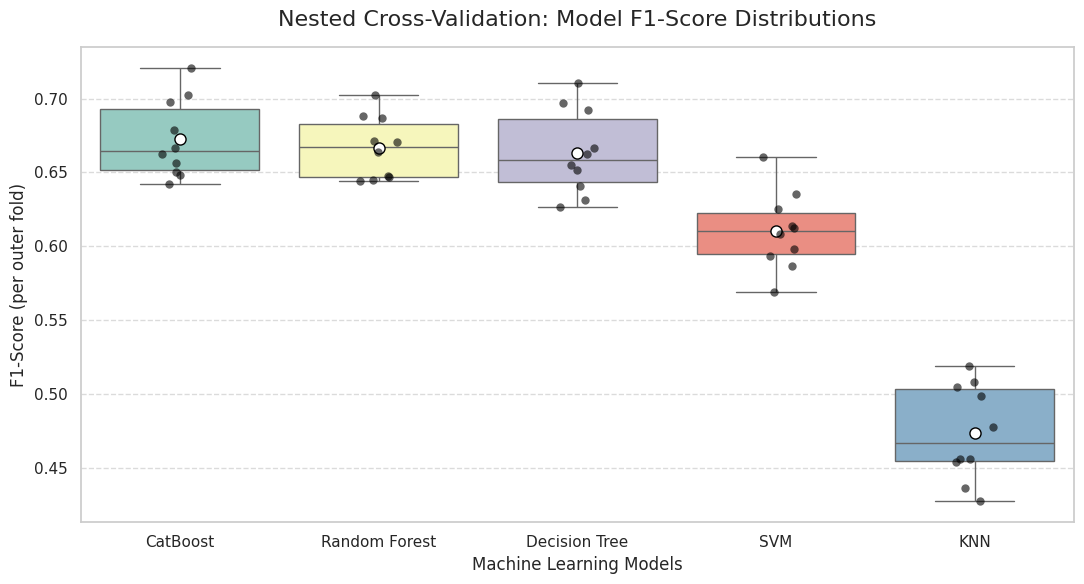

Plot saved: nested_cv_f1.png


In [ ]:
# --- Boxplot + Stripplot per metric (same style as reference) ---
metric_labels = {
    'accuracy':          'Accuracy',
    'precision':         'Precision',
    'recall':            'Recall',
    'f1':                'F1-Score',
}

for metric in SCORING_METRICS:
    df_plot = pd.DataFrame(all_results[metric])

    # Sort columns by mean descending
    order = df_plot.mean().sort_values(ascending=False).index
    df_plot = df_plot[order]

    plt.figure(figsize=(11, 6))

    sns.boxplot( data=df_plot, palette='Set3', showmeans=True,
        meanprops={
            'marker':          'o',
            'markerfacecolor': 'white',
            'markeredgecolor': 'black',
            'markersize':      8
    })

    sns.stripplot( data=df_plot, color='black', alpha=0.6, jitter=True, size=6)

    plt.title(    f'Nested Cross-Validation: Model {metric_labels[metric]} Distributions',
        fontsize=16, pad=15)
    plt.ylabel(f'{metric_labels[metric]} (per outer fold)', fontsize=12)
    plt.xlabel('Machine Learning Models', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f'/content/nested_cv_{metric}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plot saved: nested_cv_{metric}.png')

In [ ]:
# --- Wilcoxon Signed-Rank Test — top 2 models ---
print('--- Wilcoxon Signed-Rank Test (F1) ---\n')

ranked = pd.DataFrame(all_results['f1']).mean().sort_values(ascending=False)
best   = ranked.index[0]
second = ranked.index[1]

stat, p = wilcoxon(
    all_results['f1'][best],
    all_results['f1'][second]
)

print(f'Metric : f1')
print(f'  1st  : {best}  (mean={ranked.iloc[0]:.4f})')
print(f'  2nd  : {second} (mean={ranked.iloc[1]:.4f})')
print(f'  p-value : {p:.4f}')

--- Wilcoxon Signed-Rank Test (F1) ---

Metric : f1
  1st  : CatBoost  (mean=0.6726)
  2nd  : Random Forest (mean=0.6667)
  p-value : 0.0488


# 10. Conclusion and Final Model Selection

After the 10x10 Nested Cross-Validation, we can draw two conclusions regarding our data balancing strategy and our final algorithm choice.

1. **Analysis on SMOTENC**

Our ablation study clearly demonstrates why applying SMOTENC is the correct choice for this project.
Balancing the target class creates a Precision-Recall trade-off: the model's Precision decreases (meaning we get more false positives), but the Recall increases. Overall, this dynamic leads to a slight improvement in the F1-Score.

2. **Final Winner: CatBoost**

To select the absolute best algorithm, we performed the Wilcoxon Signed-Rank Test on the average F1-score across the CV folds of our top two models. The test returned a **p-value of 0.0488**. Because this value is below the 0.05 threshold, the test indicates that the performance difference is statistically significant.
We declare **CatBoost** as our final winner. Not only does it secure a statistical win in terms of the mean F1-Score, but the metrics also show that CatBoost achieves a **better average Recall** than its top competitor, making it the best choice for our predictive task.
